# FairDerm: Skin Lesion Classification

This notebook trains skin lesion classifiers on Fitzpatrick17k, evaluates them on DDI, and analyzes the results.

**Methods:**
- Baseline (cross-entropy + uniform sampling)
- Mixup (cross-entropy + mixup augmentation)
- Reweighted (weighted cross-entropy + class-weighted sampling)
- Focal Loss (gamma=2)
- LDAS (loss-driven adaptive sampling, alpha=0.7)

## Configuration

**Update the paths below for your setup.** Works on Colab, local machine, or any other platform.

In [1]:
# ============================================================
# SET YOUR PATHS HERE
# ============================================================

# Where the fairderm code package is located
CODE_DIR = '/content/drive/MyDrive/thesis/code'

# Fitzpatrick17k CSV file
FITZPATRICK_CSV = '/content/drive/MyDrive/thesis/data/fitzpatrick17k_processed.csv'

# DDI dataset paths
DDI_IMAGES_DIR = '/content/drive/MyDrive/thesis/data/ddidiversedermatologyimages'
DDI_METADATA = '/content/drive/MyDrive/thesis/data/ddi_metadata.csv'

# Where to save results
RESULTS_DIR = '/content/drive/MyDrive/thesis/results'

# Seeds to train with for reproducibility
SEEDS = [0, 7, 21, 42, 123]

# ============================================================

In [2]:
# Mount Google Drive if on Colab (comment out if not using Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive mounted')
except:
    print('Not running on Colab, skipping drive mount')

Mounted at /content/drive
Google Drive mounted


In [3]:
# Install dependencies
!pip install timm --quiet

In [4]:
import sys
sys.path.insert(0, CODE_DIR)
import os
import json
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from tqdm import tqdm
warnings.filterwarnings('ignore')
from fairderm import (
    bootstrap_ci,
    SkinLesionDataset,
    SkinLesionClassifier,
    DDIDataset,
    create_model,
    get_class_weights,
    get_train_transforms,
    get_eval_transforms,
    get_ddi_eval_transforms,
    run_experiment,
    save_experiment_results,
    compute_metrics,
    compute_fairness_metrics,
)
from fairderm.configs import (
    get_baseline_config,
    get_mixup_config,
    get_reweighted_config,
    get_focal_config,
    get_groupdro_config,
    get_ldas_config,
)
os.makedirs(RESULTS_DIR, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: cuda


---
# Part 1: Training
---

## Load and prepare data

In [5]:
df = pd.read_csv(FITZPATRICK_CSV)

print(f'Total samples: {len(df)}')
print(f'\nLabels:\n{df["label_num"].value_counts()}')
print(f'\nSkin tones:\n{df["tone_group"].value_counts()}')

Total samples: 4491

Labels:
label_num
1    2260
0    2231
Name: count, dtype: int64

Skin tones:
tone_group
Light      2308
Medium     1599
Dark        409
Unknown     175
Name: count, dtype: int64


In [6]:
# train/val split stratified by label and skin tone
df['stratify_key'] = df['label'].astype(str) + '_' + df['tone_group']

train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['stratify_key']
)

train_df = train_df.drop('stratify_key', axis=1).reset_index(drop=True)
val_df = val_df.drop('stratify_key', axis=1).reset_index(drop=True)

print(f'Train: {len(train_df)}, Val: {len(val_df)}')

Train: 3592, Val: 899


In [7]:
train_transform = get_train_transforms()
eval_transform = get_eval_transforms()

train_dataset = SkinLesionDataset(train_df, transform=train_transform, return_group=True)
val_dataset = SkinLesionDataset(val_df, transform=eval_transform, return_group=True)

class_weights = get_class_weights(train_df, label_col='label_num')
print(f'Class weights: {class_weights}')

Class weights: tensor([1.0073, 0.9928])


## Train all methods

In [8]:
MODELS = ['baseline', 'mixup', 'reweighted', 'focalloss', 'groupdro', 'LDAS']
def get_config(name):
    if name == 'baseline':
        return get_baseline_config()
    elif name == 'mixup':
        return get_mixup_config()
    elif name == 'reweighted':
        return get_reweighted_config(class_weights, device=device)
    elif name == 'focalloss':
        return get_focal_config()
    elif name == 'groupdro':
        return get_groupdro_config()
    elif name == 'LDAS':
        return get_ldas_config()
    else:
        raise ValueError(f'Unknown model: {name}')


In [9]:
# Train all models across all seeds
all_results = {}

SKIP_EXISTING_RUNS = True
REQUIRED_ARTIFACTS = ['model.pt', 'metrics.json', 'training_history.csv']

for model_name in MODELS:
    for seed in SEEDS:
        run_name = f'{model_name}_seed{seed}'
        run_dir = Path(RESULTS_DIR) / run_name

        artifacts_exist = all((run_dir / f).exists() for f in REQUIRED_ARTIFACTS)
        if SKIP_EXISTING_RUNS and artifacts_exist:
            print(f'\nSkipping existing run: {run_name}')
            continue

        if SKIP_EXISTING_RUNS and run_dir.exists() and not artifacts_exist:
            print(f'\nFound incomplete run, retraining: {run_name}')

        print(f'\n{"="*60}')
        print(f'Training: {run_name}')
        print(f'{"="*60}')

        config = get_config(model_name)
        results = run_experiment(train_dataset, val_dataset, config, seed=seed, device=device)
        all_results[run_name] = results

        save_experiment_results(results, run_name, RESULTS_DIR)
        print(f'Saved to {RESULTS_DIR}/{run_name}')

print(f'\n{"="*60}')
print('Training complete!')
print(f'{"="*60}')


Skipping existing run: baseline_seed0

Skipping existing run: baseline_seed7

Skipping existing run: baseline_seed21

Skipping existing run: baseline_seed42

Skipping existing run: baseline_seed123

Skipping existing run: mixup_seed0

Skipping existing run: mixup_seed7

Skipping existing run: mixup_seed21

Skipping existing run: mixup_seed42

Skipping existing run: mixup_seed123

Skipping existing run: reweighted_seed0

Skipping existing run: reweighted_seed7

Skipping existing run: reweighted_seed21

Skipping existing run: reweighted_seed42

Skipping existing run: reweighted_seed123

Skipping existing run: focalloss_seed0

Skipping existing run: focalloss_seed7

Skipping existing run: focalloss_seed21

Skipping existing run: focalloss_seed42

Skipping existing run: focalloss_seed123

Skipping existing run: proposed_seed0

Skipping existing run: proposed_seed7

Skipping existing run: proposed_seed21

Skipping existing run: proposed_seed42

Skipping existing run: proposed_seed123

Skip

---
# Part 2: DDI Evaluation
---

In [10]:
# Load DDI dataset
ddi_transforms = get_ddi_eval_transforms()

ddi_dataset = DDIDataset(
    metadata_path=DDI_METADATA,
    images_dir=DDI_IMAGES_DIR,
    transform=ddi_transforms
)

ddi_loader = DataLoader(ddi_dataset, batch_size=32, shuffle=False, num_workers=2)

stats = ddi_dataset.get_statistics()
print(f'DDI samples: {stats["total"]}')
print(f'Per group: {stats["per_group"]}')


DDI Dataset loaded: 656 images

Skin tone distribution:
skin_tone_group
Medium    241
Light     208
Dark      207
Name: count, dtype: int64

Class distribution:
label
Benign       485
Malignant    171
Name: count, dtype: int64
DDI samples: 656
Per group: {'Medium': 241, 'Light': 208, 'Dark': 207}


In [11]:
def load_model(model_path):
    model = SkinLesionClassifier(num_classes=2, pretrained=False)
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()
    return model

def evaluate_model(model, dataloader):
    model.eval()
    all_preds, all_labels, all_groups, all_probs = [], [], [], []

    with torch.no_grad():
        for images, labels, groups in tqdm(dataloader, desc='Evaluating'):
            images = images.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_groups.extend(groups.numpy())
            all_probs.extend(probs.cpu().numpy())

    return {
        'preds': np.array(all_preds),
        'labels': np.array(all_labels),
        'groups': np.array(all_groups),
        'probs': np.array(all_probs)
    }

In [12]:
# Evaluate all models on DDI
ddi_results = {model: {} for model in MODELS}

for model_name in MODELS:
    for seed in SEEDS:
        run_name = f'{model_name}_seed{seed}'
        model_path = Path(RESULTS_DIR) / run_name / 'model.pt'

        if not model_path.exists():
            print(f'Model not found: {model_path}')
            continue

        print(f'\nEvaluating {run_name} on DDI...')
        model = load_model(model_path)
        eval_results = evaluate_model(model, ddi_loader)

        overall = compute_metrics(eval_results['labels'], eval_results['preds'], eval_results['probs'])
        fairness = compute_fairness_metrics(eval_results['labels'], eval_results['preds'], eval_results['groups'])

        ddi_results[model_name][seed] = {'overall': overall, 'fairness': fairness}

        print(f'  Balanced Acc: {overall["balanced_accuracy"]:.4f}, EO Gap: {fairness["equal_opportunity_gap"]:.4f}')

        del model
        torch.cuda.empty_cache()

print('\nDDI evaluation complete!')


Evaluating baseline_seed0 on DDI...


Evaluating: 100%|██████████| 21/21 [01:41<00:00,  4.82s/it]


  Balanced Acc: 0.6113, EO Gap: 0.3588

Evaluating baseline_seed7 on DDI...


Evaluating: 100%|██████████| 21/21 [00:07<00:00,  2.77it/s]


  Balanced Acc: 0.6228, EO Gap: 0.3389

Evaluating baseline_seed21 on DDI...


...

  Balanced Acc: 0.6156, EO Gap: 0.2343

Evaluating adaptive_a05_t20_seed42 on DDI...


Evaluating: 100%|██████████| 21/21 [00:07<00:00,  2.76it/s]


  Balanced Acc: 0.6125, EO Gap: 0.2980

Evaluating adaptive_a05_t20_seed123 on DDI...


Evaluating: 100%|██████████| 21/21 [00:07<00:00,  2.79it/s]

  Balanced Acc: 0.6257, EO Gap: 0.3380

DDI evaluation complete!


In [13]:
# Save DDI results
ddi_dir = Path(RESULTS_DIR) / 'ddi_evaluation'
ddi_dir.mkdir(exist_ok=True)

rows = []
for model_name in MODELS:
    for seed, r in ddi_results[model_name].items():
        rows.append({
            'model': model_name,
            'seed': seed,
            'balanced_accuracy': r['overall']['balanced_accuracy'],
            'roc_auc': r['overall'].get('roc_auc'),
            'equal_opportunity_gap': r['fairness']['equal_opportunity_gap'],
            'tpr_light': r['fairness']['tpr_per_group'].get('Light'),
            'tpr_medium': r['fairness']['tpr_per_group'].get('Medium'),
            'tpr_dark': r['fairness']['tpr_per_group'].get('Dark'),
        })

ddi_df = pd.DataFrame(rows)
ddi_df.to_csv(ddi_dir / 'ddi_results.csv', index=False)
print(f'Saved DDI results to {ddi_dir / "ddi_results.csv"}')

Saved DDI results to /content/drive/MyDrive/thesis/results/ddi_evaluation/ddi_results.csv


---
# Part 3: Analysis
---

In [14]:
# Load Fitzpatrick17k results
def load_fitz_results(model, seed):
    path = Path(RESULTS_DIR) / f'{model}_seed{seed}' / 'metrics.json'
    if path.exists():
        with open(path, 'r') as f:
            return json.load(f)
    return None

fitz_results = {}
for model in MODELS:
    fitz_results[model] = {}
    for seed in SEEDS:
        result = load_fitz_results(model, seed)
        if result:
            fitz_results[model][seed] = result

In [15]:
# Aggregate results using 95% bootstrap confidence intervals
def make_metric(values):
    mean, ci_lower, ci_upper = bootstrap_ci(values)
    return {'mean': mean, 'ci_lower': ci_lower, 'ci_upper': ci_upper, 'values': list(values)}

def aggregate(model_results):
    if not model_results:
        return None

    seeds_data = list(model_results.values())
    result = {'n_seeds': len(seeds_data)}

    # overall metrics
    for key in ['balanced_accuracy', 'roc_auc']:
        values = [s['overall'].get(key) for s in seeds_data if s['overall'].get(key) is not None]
        if values:
            result[key] = make_metric(values)

    # fairness metrics
    for key in ['equal_opportunity_gap']:
        values = [s['fairness'].get(key) for s in seeds_data if s['fairness'].get(key) is not None]
        if values:
            result[key] = make_metric(values)

    # per-group TPR
    group_tpr_values = {}
    for group in ['Light', 'Medium', 'Dark']:
        values = [s['fairness']['tpr_per_group'].get(group) for s in seeds_data
                  if s['fairness']['tpr_per_group'].get(group) is not None]
        if values:
            result[f'tpr_{group.lower()}'] = make_metric(values)
            group_tpr_values[group] = values

    # worst-group TPR: identify worst group by mean across seeds, then bootstrap CI on that group
    if group_tpr_values:
        import numpy as np
        worst_group = min(group_tpr_values, key=lambda g: np.mean(group_tpr_values[g]))
        result['worst_group_tpr'] = make_metric(group_tpr_values[worst_group])

    return result

fitz_agg = {m: aggregate(fitz_results[m]) for m in MODELS}
ddi_agg  = {m: aggregate(ddi_results[m])  for m in MODELS}

In [16]:
# Print summary
def fmt(d):
    if d is None:
        return 'N/A'
    return f"{d['mean']:.4f} [{d['ci_lower']:.4f}, {d['ci_upper']:.4f}]"

print('='*90)
print('FITZPATRICK17K RESULTS  (mean [95% bootstrap CI])')
print('='*90)
print(f'{"Model":<20} {"Balanced Acc":>28} {"Worst-Group TPR":>28} {"EO Gap":>26}')
print('-'*90)
for model in MODELS:
    m = fitz_agg[model]
    if m:
        print(f'{model:<20} {fmt(m.get("balanced_accuracy")):>28}'
              f' {fmt(m.get("worst_group_tpr")):>28} {fmt(m.get("equal_opportunity_gap")):>26}')

print('\n' + '='*90)
print('DDI RESULTS  (mean [95% bootstrap CI])')
print('='*90)
print(f'{"Model":<20} {"Balanced Acc":>28} {"TPR Dark":>28} {"EO Gap":>26}')
print('-'*90)
for model in MODELS:
    m = ddi_agg[model]
    if m:
        print(f'{model:<20} {fmt(m.get("balanced_accuracy")):>28}'
              f' {fmt(m.get("tpr_dark")):>28} {fmt(m.get("equal_opportunity_gap")):>26}')


FITZPATRICK17K RESULTS  (mean [95% bootstrap CI])
Model                                Balanced Acc              Worst-Group TPR                     EO Gap
------------------------------------------------------------------------------------------
baseline                  0.8301 [0.8202, 0.8430]      0.7366 [0.7073, 0.7854]    0.0873 [0.0557, 0.1152]
mixup                     0.8575 [0.8535, 0.8615]      0.7951 [0.7561, 0.8390]    0.0707 [0.0352, 0.1084]
reweighted                0.8299 [0.8199, 0.8436]      0.7317 [0.6976, 0.7805]    0.0895 [0.0606, 0.1166]
focalloss                 0.8226 [0.8104, 0.8328]      0.7073 [0.6195, 0.7561]    0.1086 [0.0647, 0.1765]
proposed                  0.8617 [0.8535, 0.8677]      0.8049 [0.7756, 0.8293]    0.0748 [0.0530, 0.0972]
groupdro                  0.8166 [0.8072, 0.8256]      0.7561 [0.7122, 0.8000]    0.0505 [0.0220, 0.0890]
adaptive_a07_t20          0.8319 [0.8201, 0.8408]      0.7808 [0.7640, 0.7975]    0.0677 [0.0478, 0.0868]
adaptive_a0

In [20]:
# Per-seed per-group TPR breakdown (ID and OOD)
print('=' * 65)
print('FITZPATRICK17K (ID) — Per-Seed Per-Group TPR')
print('=' * 65)
for model in MODELS:
    print(f'\n{model}')
    print(f'  {"Seed":<6} {"Light":>8} {"Medium":>8} {"Dark":>8}')
    for seed in SEEDS:
        r = fitz_results[model].get(seed)
        if r:
            tpr = r['fairness']['tpr_per_group']
            print(f'  {seed:<6} {tpr["Light"]:>8.4f} {tpr["Medium"]:>8.4f} {tpr["Dark"]:>8.4f}')
    # group means
    if fitz_results[model]:
        seeds_data = list(fitz_results[model].values())
        means = {g: np.mean([s['fairness']['tpr_per_group'].get(g) for s in seeds_data if s['fairness']['tpr_per_group'].get(g) is not None])
                 for g in ['Light', 'Medium', 'Dark']}
        worst = min(means, key=means.get)
        print(f'  {"Mean":<6} {means["Light"]:>8.4f} {means["Medium"]:>8.4f} {means["Dark"]:>8.4f}  <- worst: {worst} ({means[worst]:.4f})')

print()
print('=' * 65)
print('DDI (OOD) — Per-Seed Per-Group TPR')
print('=' * 65)
for model in MODELS:
    print(f'\n{model}')
    print(f'  {"Seed":<6} {"Light":>8} {"Medium":>8} {"Dark":>8}')
    for seed in SEEDS:
        r = ddi_results[model].get(seed)
        if r:
            tpr = r['fairness']['tpr_per_group']
            print(f'  {seed:<6} {tpr.get("Light", float("nan")):>8.4f} {tpr.get("Medium", float("nan")):>8.4f} {tpr.get("Dark", float("nan")):>8.4f}')
    if ddi_results[model]:
        seeds_data = list(ddi_results[model].values())
        means = {g: np.mean([s['fairness']['tpr_per_group'].get(g) for s in seeds_data if s['fairness']['tpr_per_group'].get(g) is not None])
                 for g in ['Light', 'Medium', 'Dark']}
        worst = min(means, key=means.get)
        print(f'  {"Mean":<6} {means["Light"]:>8.4f} {means["Medium"]:>8.4f} {means["Dark"]:>8.4f}  <- worst: {worst} ({means[worst]:.4f})')

FITZPATRICK17K (ID) — Per-Seed Per-Group TPR

baseline
  Seed      Light   Medium     Dark
  0        0.7741   0.8079   0.7073
  7        0.7866   0.8411   0.7073
  21       0.7197   0.7947   0.7073
  42       0.8494   0.8609   0.8293
  123      0.7908   0.8146   0.7317
  Mean     0.7841   0.8238   0.7366  <- worst: Dark (0.7366)

mixup
  Seed      Light   Medium     Dark
  0        0.8368   0.8675   0.7317
  7        0.8075   0.8742   0.8780
  21       0.8326   0.8477   0.7805
  42       0.8075   0.7947   0.8049
  123      0.8326   0.8477   0.7805
  Mean     0.8234   0.8464   0.7951  <- worst: Dark (0.7951)

reweighted
  Seed      Light   Medium     Dark
  0        0.7741   0.7947   0.7073
  7        0.7824   0.8411   0.7073
  21       0.7238   0.7881   0.6829
  42       0.8452   0.8675   0.8293
  123      0.7908   0.8146   0.7317
  Mean     0.7833   0.8212   0.7317  <- worst: Dark (0.7317)

focalloss
  Seed      Light   Medium     Dark
  0        0.7364   0.7748   0.5366
  7        0

## Figures

In [21]:
# Publication-quality figure settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['font.family'] = 'sans-serif'
MODEL_COLORS = {
    'baseline':         '#7f8c8d',
    'mixup':            '#3498db',
    'reweighted':       '#9b59b6',
    'focalloss':        '#e74c3c',
    'groupdro':         '#e67e22',
    'LDAS':             '#1abc9c',
}
MODEL_LABELS = {
    'baseline':         'Baseline',
    'mixup':            'Mixup',
    'reweighted':       'Reweighted',
    'focalloss':        'Focal Loss',
    'groupdro':         'GroupDRO',
    'LDAS':             'LDAS',
}
figures_dir = Path(RESULTS_DIR) / 'figures'
figures_dir.mkdir(exist_ok=True)


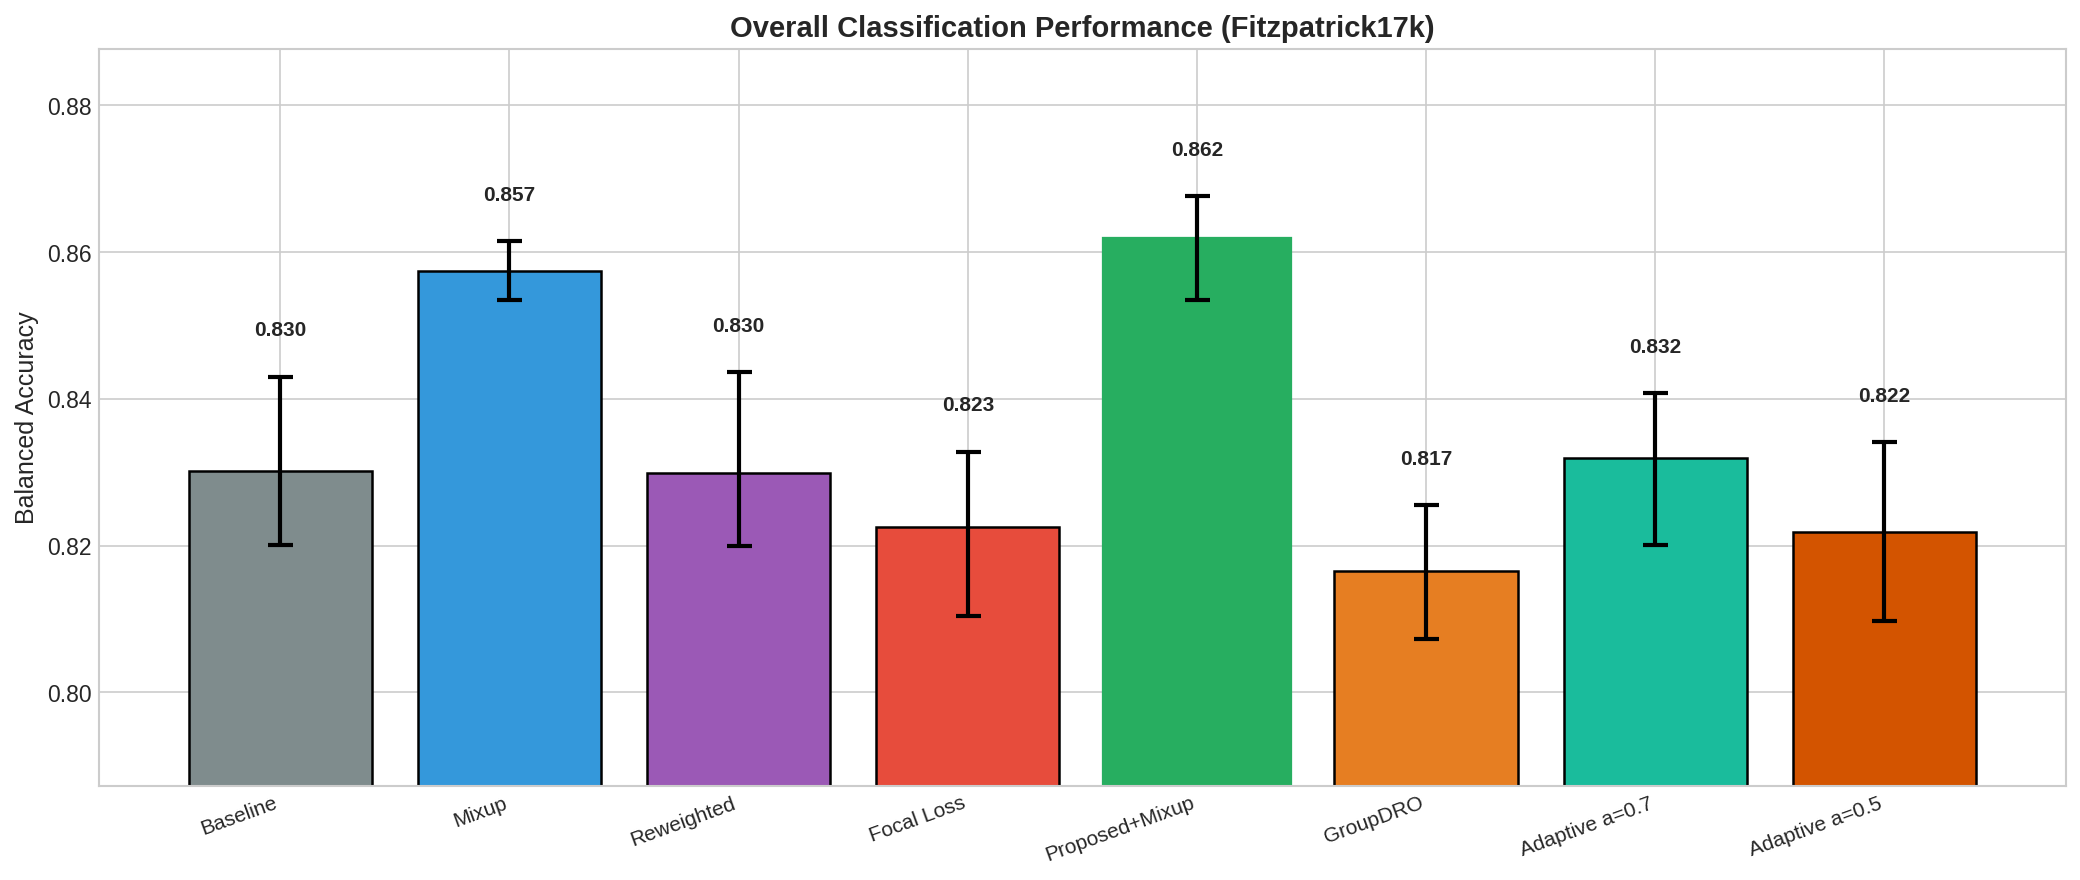

In [22]:
# Figure 1: Balanced accuracy comparison
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(MODELS))
mdata  = [fitz_agg[m]['balanced_accuracy'] for m in MODELS]
values = [d['mean'] for d in mdata]
yerr   = ([d['mean'] - d['ci_lower'] for d in mdata],
           [d['ci_upper'] - d['mean'] for d in mdata])
colors = [MODEL_COLORS[m] for m in MODELS]

bars = ax.bar(x, values, yerr=yerr, color=colors, edgecolor='black',
              linewidth=1.2, capsize=6, error_kw={'linewidth': 2, 'capthick': 2})

# Highlight best model
best_idx = np.argmax(values)
bars[best_idx].set_edgecolor('#27ae60')
bars[best_idx].set_linewidth(3)

ax.set_ylabel('Balanced Accuracy', fontsize=12)
ax.set_title('Overall Classification Performance (Fitzpatrick17k)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([MODEL_LABELS[m] for m in MODELS], fontsize=10, rotation=20, ha='right')

y_min = min(d['ci_lower'] for d in mdata) - 0.02
y_max = max(d['ci_upper'] for d in mdata) + 0.02
ax.set_ylim(max(0, y_min), min(1, y_max))

for bar, d in zip(bars, mdata):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (d['ci_upper'] - d['mean']) + 0.005,
            f'{d["mean"]:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(figures_dir / 'fig1_performance.png')
plt.show()


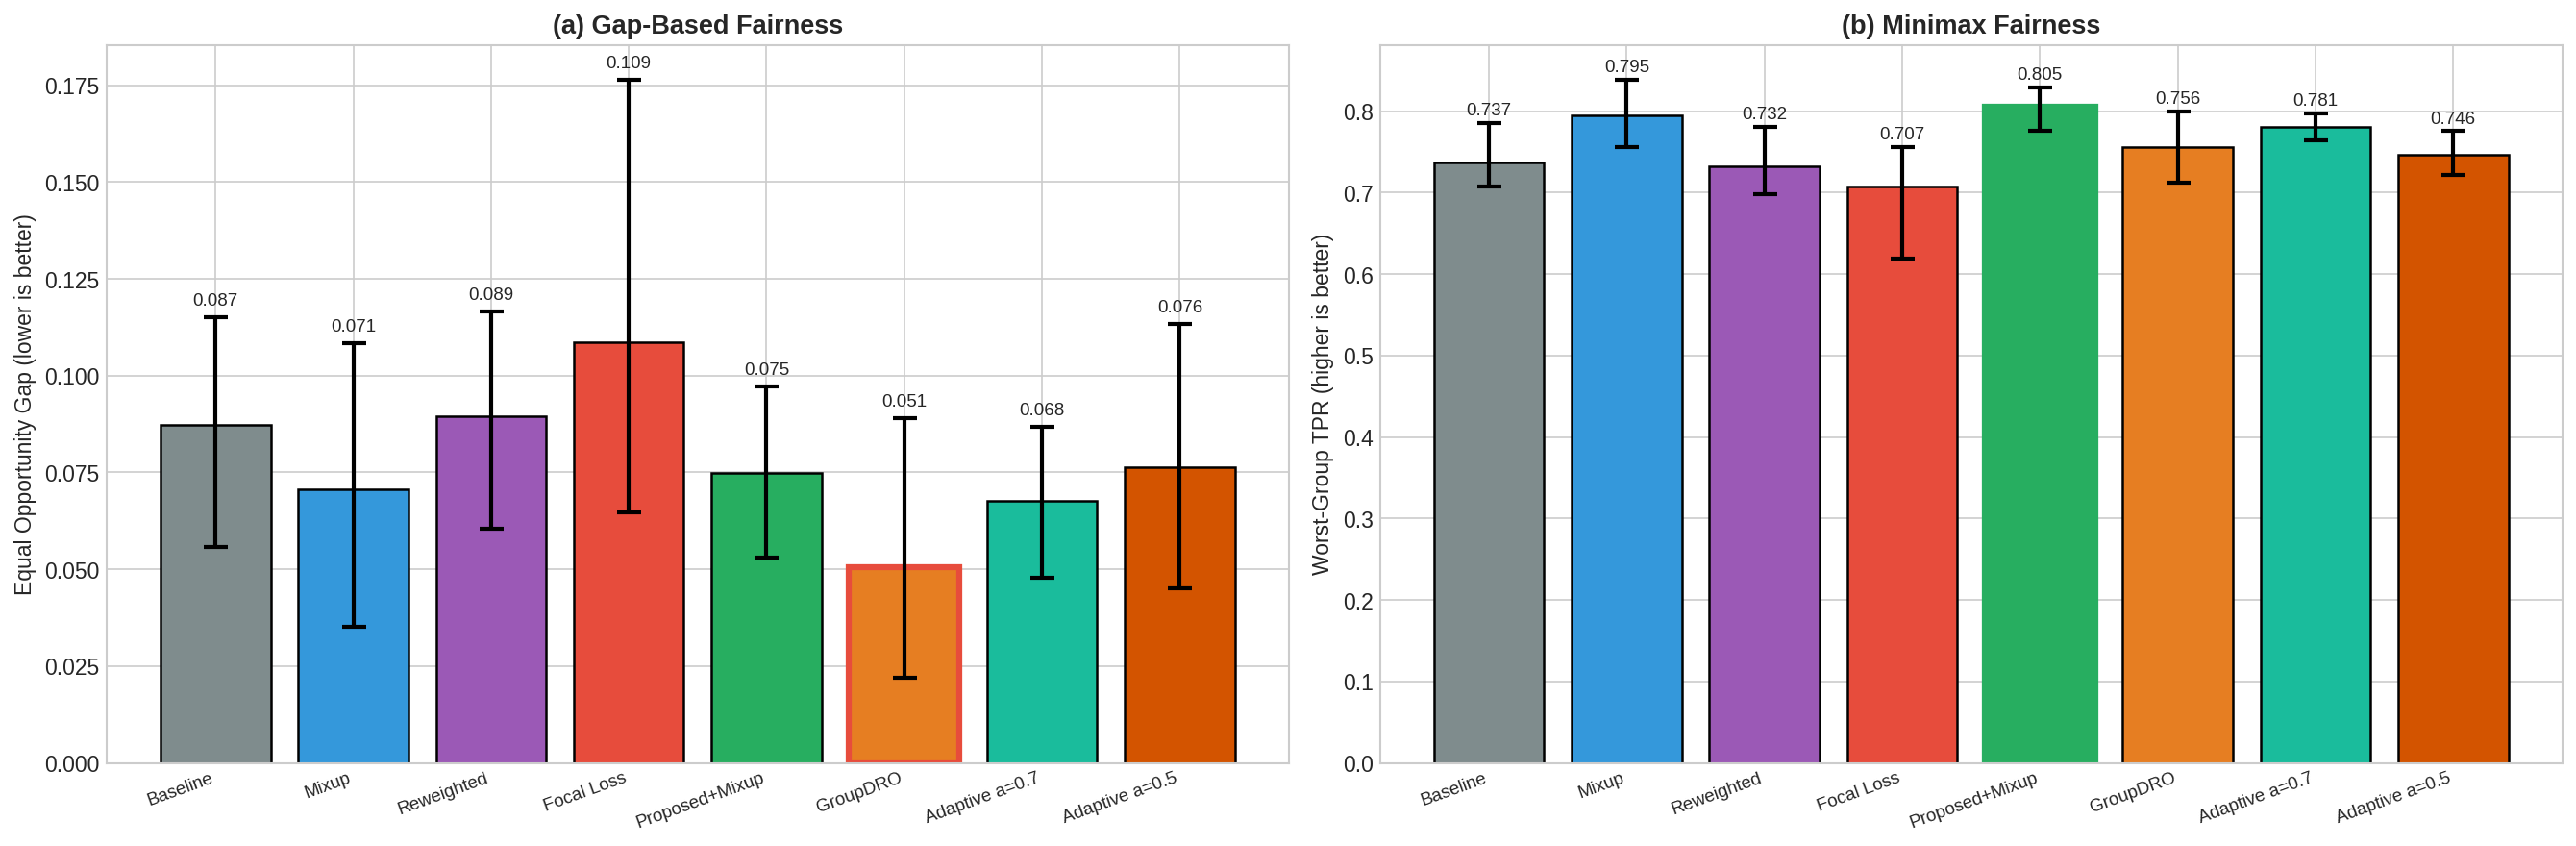

In [23]:
# Figure 2: Fairness comparison (EO Gap vs Worst-Group TPR)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

x      = np.arange(len(MODELS))
colors = [MODEL_COLORS[m] for m in MODELS]
labels = [MODEL_LABELS[m] for m in MODELS]

# EO Gap (lower is better)
ax    = axes[0]
mdata = [fitz_agg[m]['equal_opportunity_gap'] for m in MODELS]
values = [d['mean'] for d in mdata]
yerr   = ([d['mean'] - d['ci_lower'] for d in mdata],
           [d['ci_upper'] - d['mean'] for d in mdata])
bars = ax.bar(x, values, yerr=yerr, color=colors, edgecolor='black',
              linewidth=1.2, capsize=6, error_kw={'linewidth': 2, 'capthick': 2})

best_idx = np.argmin(values)
bars[best_idx].set_edgecolor('#e74c3c')
bars[best_idx].set_linewidth(3)

ax.set_ylabel('Equal Opportunity Gap (lower is better)', fontsize=11)
ax.set_title('(a) Gap-Based Fairness', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9, rotation=20, ha='right')

for bar, d in zip(bars, mdata):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (d['ci_upper'] - d['mean']) + 0.002,
            f'{d["mean"]:.3f}', ha='center', va='bottom', fontsize=9)

# Worst-Group TPR (higher is better)
ax    = axes[1]
mdata = [fitz_agg[m]['worst_group_tpr'] for m in MODELS]
values = [d['mean'] for d in mdata]
yerr   = ([d['mean'] - d['ci_lower'] for d in mdata],
           [d['ci_upper'] - d['mean'] for d in mdata])
bars = ax.bar(x, values, yerr=yerr, color=colors, edgecolor='black',
              linewidth=1.2, capsize=6, error_kw={'linewidth': 2, 'capthick': 2})

best_idx = np.argmax(values)
bars[best_idx].set_edgecolor('#27ae60')
bars[best_idx].set_linewidth(3)

ax.set_ylabel('Worst-Group TPR (higher is better)', fontsize=11)
ax.set_title('(b) Minimax Fairness', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9, rotation=20, ha='right')

for bar, d in zip(bars, mdata):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (d['ci_upper'] - d['mean']) + 0.005,
            f'{d["mean"]:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(figures_dir / 'fig2_fairness.png')
plt.show()


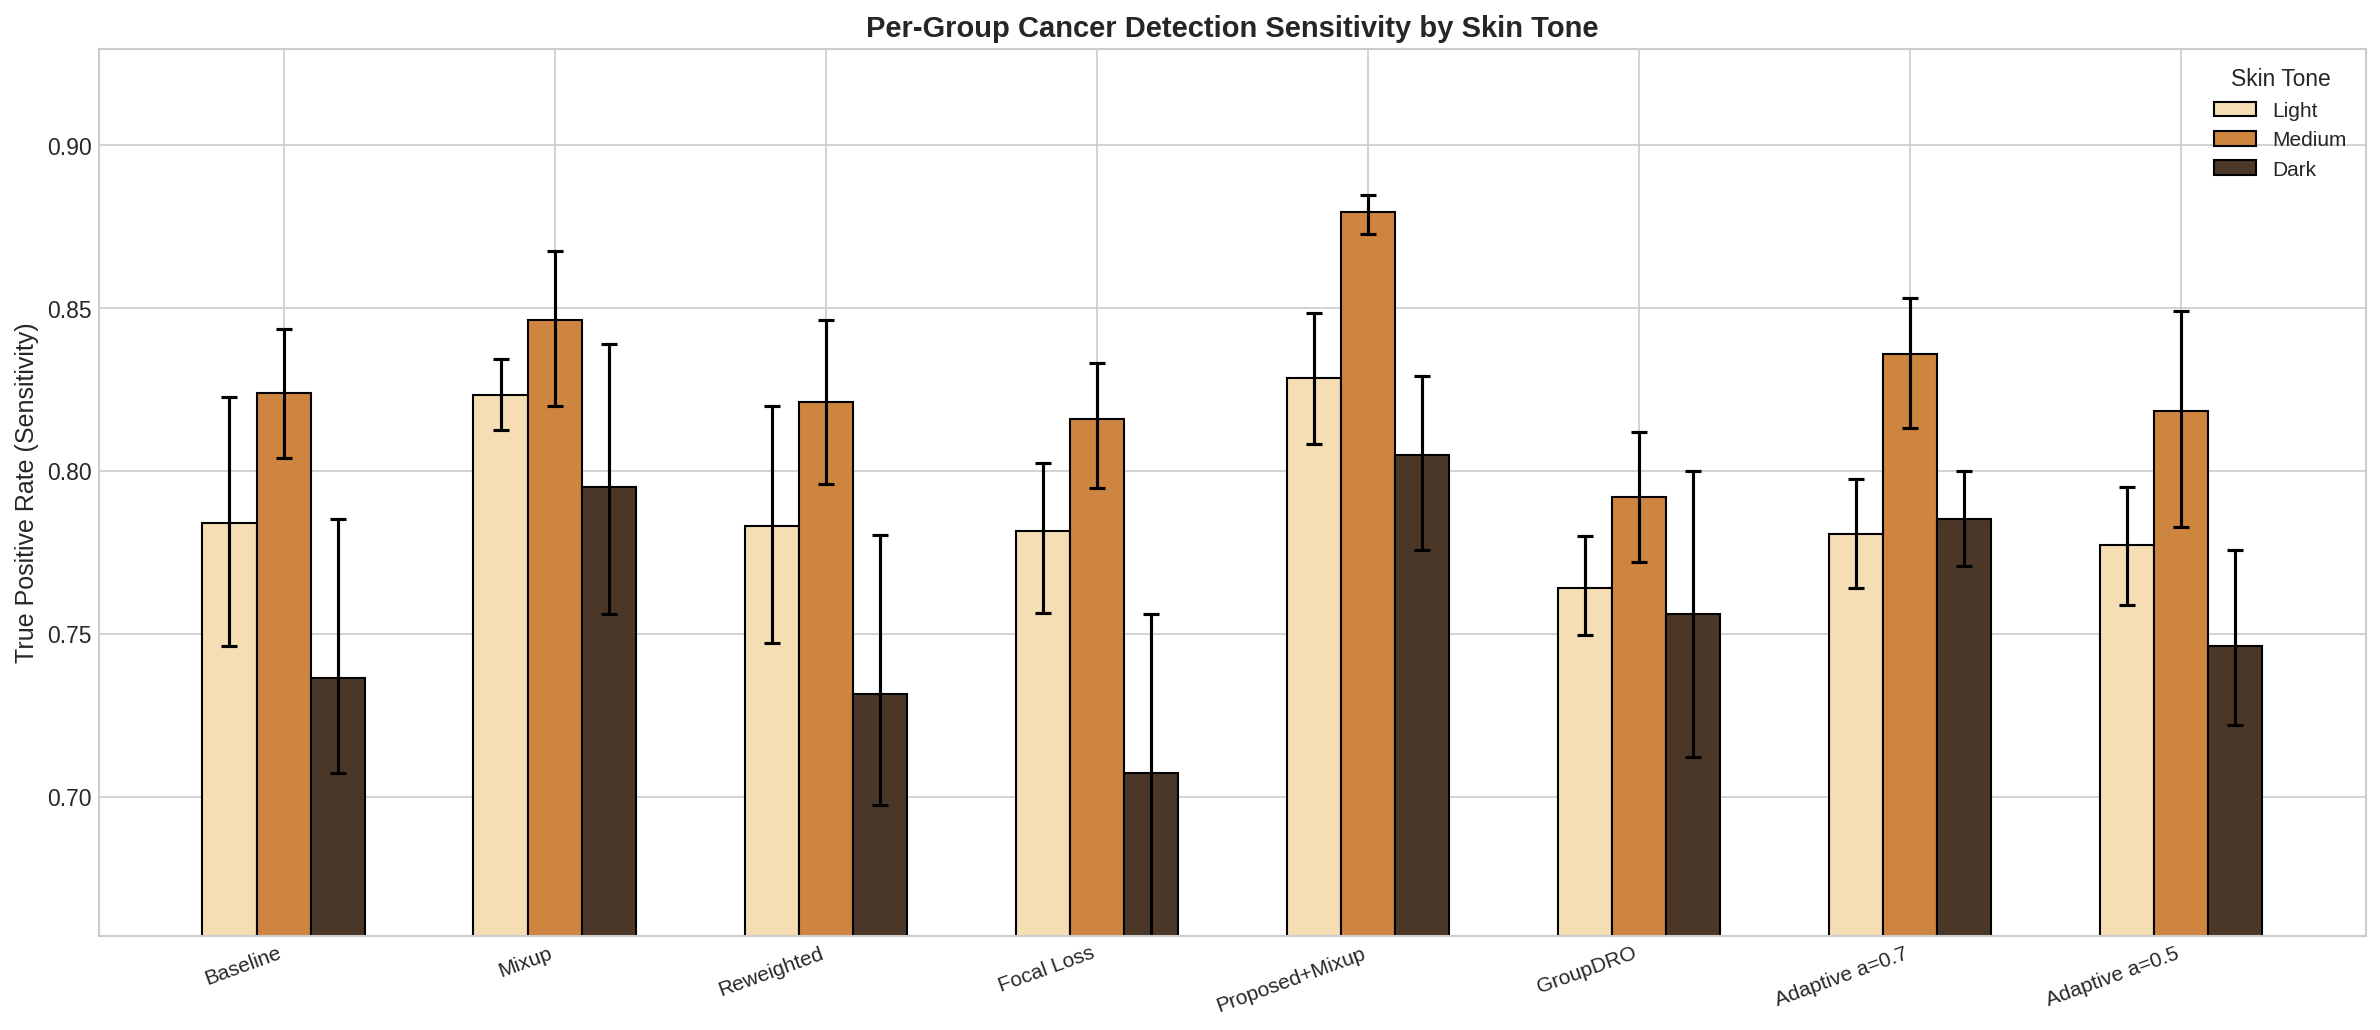

In [24]:
# Figure 3: Per-group sensitivity
fig, ax = plt.subplots(figsize=(16, 7))

x           = np.arange(len(MODELS))
width       = 0.20
skin_colors = ['#F5DEB3', '#CD853F', '#4A3728']

for i, (group, color) in enumerate(zip(['light', 'medium', 'dark'], skin_colors)):
    mdata  = [fitz_agg[m][f'tpr_{group}'] for m in MODELS]
    values = [d['mean'] for d in mdata]
    yerr   = ([d['mean'] - d['ci_lower'] for d in mdata],
               [d['ci_upper'] - d['mean'] for d in mdata])
    ax.bar(x + (i-1)*width, values, width, yerr=yerr, label=group.capitalize(),
           color=color, edgecolor='black', linewidth=1, capsize=4,
           error_kw={'linewidth': 1.5, 'capthick': 1.5})

ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('Per-Group Cancer Detection Sensitivity by Skin Tone', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([MODEL_LABELS[m] for m in MODELS], fontsize=10, rotation=20, ha='right')
ax.legend(title='Skin Tone', fontsize=10)

all_values = [fitz_agg[m][f'tpr_{g}']['mean'] for m in MODELS for g in ['light', 'medium', 'dark']]
ax.set_ylim(min(all_values) - 0.05, max(all_values) + 0.05)

plt.tight_layout()
plt.savefig(figures_dir / 'fig3_per_group_tpr.png')
plt.show()


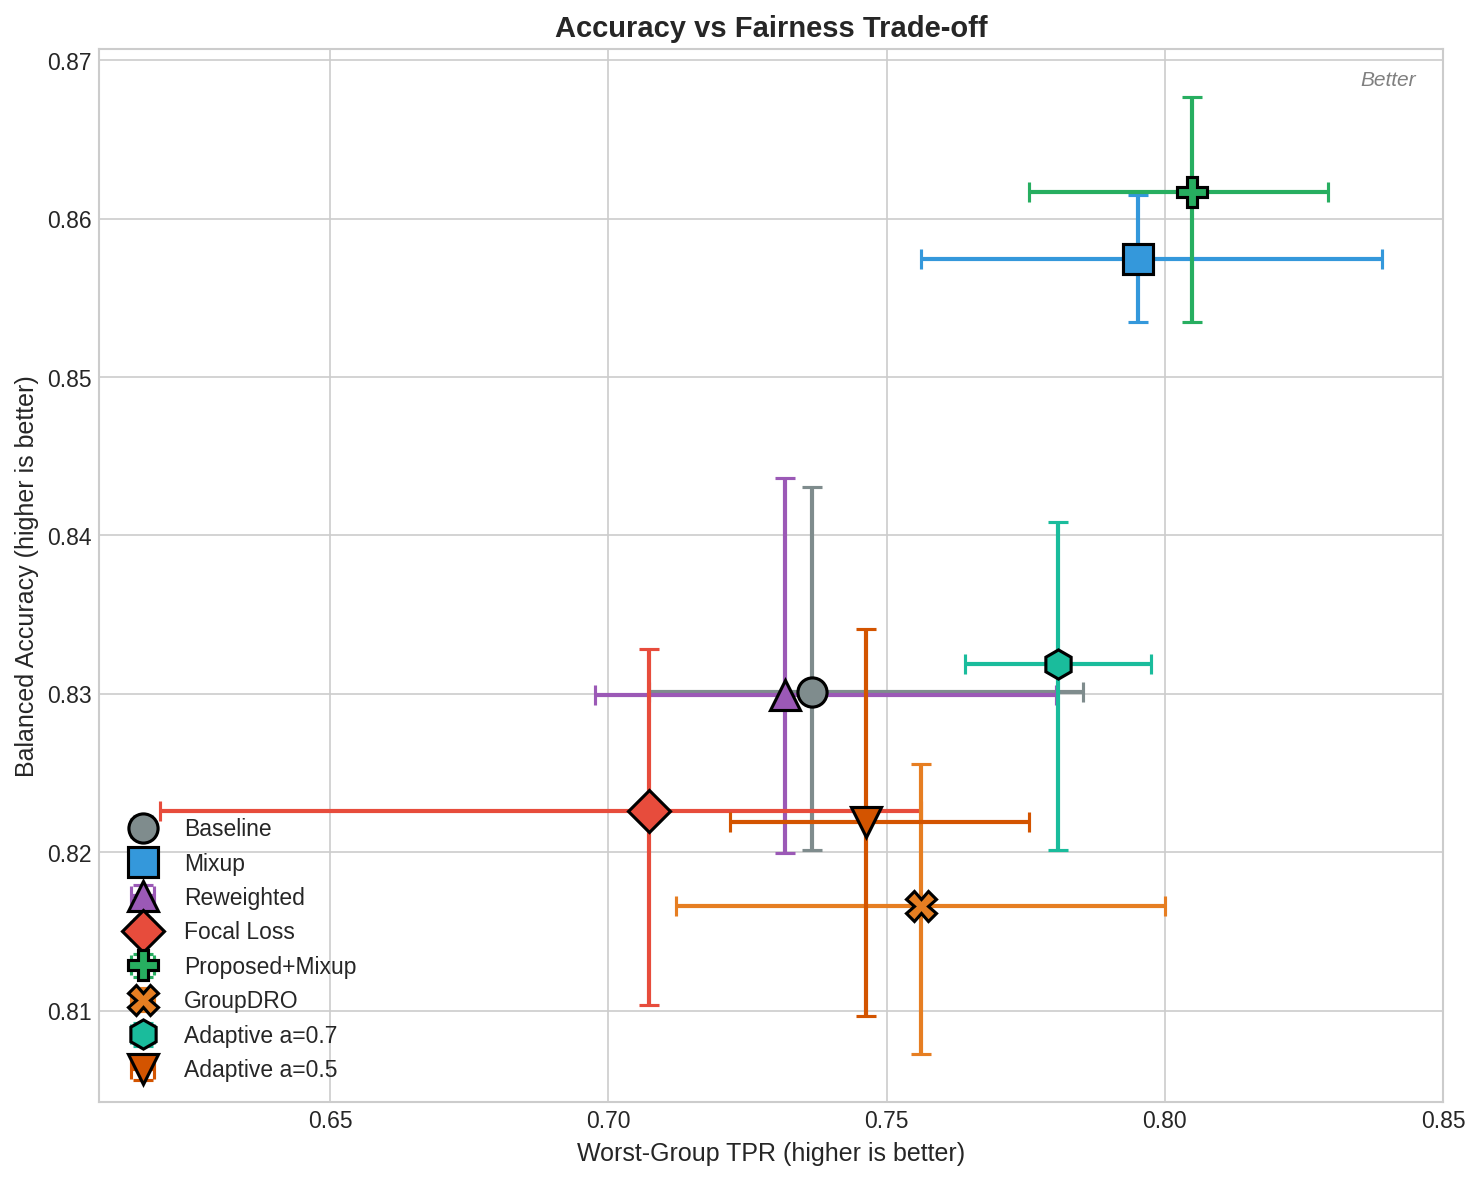

In [25]:
# Figure 4: Accuracy vs fairness scatter
fig, ax = plt.subplots(figsize=(10, 8))

markers = ['o', 's', '^', 'D', 'P', 'X', 'h', 'v']

for i, model in enumerate(MODELS):
    m  = fitz_agg[model]
    wg = m['worst_group_tpr']
    ba = m['balanced_accuracy']
    ax.errorbar(
        wg['mean'], ba['mean'],
        xerr=[[wg['mean'] - wg['ci_lower']], [wg['ci_upper'] - wg['mean']]],
        yerr=[[ba['mean'] - ba['ci_lower']], [ba['ci_upper'] - ba['mean']]],
        fmt=markers[i], markersize=14, color=MODEL_COLORS[model],
        label=MODEL_LABELS[model], capsize=5, markeredgecolor='black',
        markeredgewidth=1.5, elinewidth=2
    )

ax.set_xlabel('Worst-Group TPR (higher is better)', fontsize=12)
ax.set_ylabel('Balanced Accuracy (higher is better)', fontsize=12)
ax.set_title('Accuracy vs Fairness Trade-off', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=11)

ax.annotate('Better', xy=(0.98, 0.98), xycoords='axes fraction',
            fontsize=10, ha='right', va='top', style='italic', color='gray')

plt.tight_layout()
plt.savefig(figures_dir / 'fig4_tradeoff.png')
plt.show()


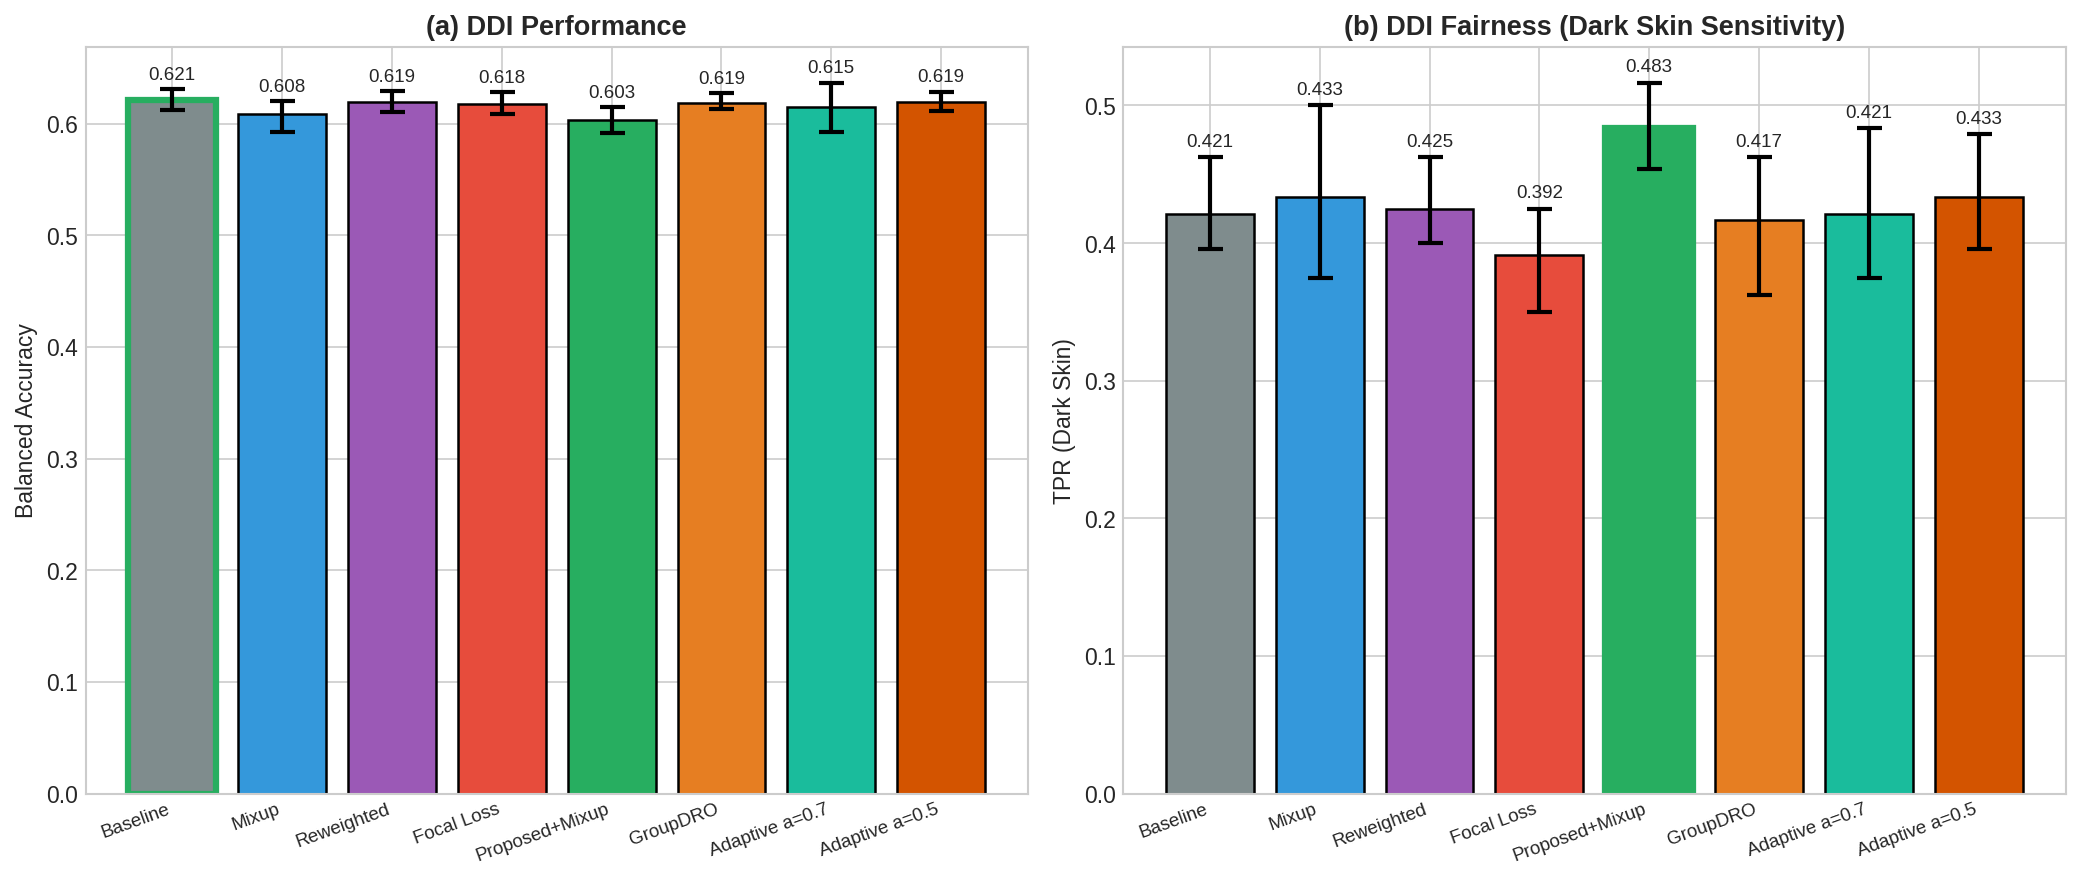

In [26]:
# Figure 5: DDI External Evaluation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# DDI Balanced Accuracy
ax = axes[0]
avail = [m for m in MODELS if ddi_agg[m]]
mdata  = [ddi_agg[m]['balanced_accuracy'] for m in avail]
values = [d['mean'] for d in mdata]
yerr   = ([d['mean'] - d['ci_lower'] for d in mdata],
           [d['ci_upper'] - d['mean'] for d in mdata])
x_a    = np.arange(len(avail))
colors_a = [MODEL_COLORS[m] for m in avail]
labels_a = [MODEL_LABELS[m] for m in avail]

bars = ax.bar(x_a, values, yerr=yerr, color=colors_a, edgecolor='black',
              linewidth=1.2, capsize=6, error_kw={'linewidth': 2, 'capthick': 2})

best_idx = np.argmax(values)
bars[best_idx].set_edgecolor('#27ae60')
bars[best_idx].set_linewidth(3)

ax.set_ylabel('Balanced Accuracy', fontsize=11)
ax.set_title('(a) DDI Performance', fontsize=13, fontweight='bold')
ax.set_xticks(x_a)
ax.set_xticklabels(labels_a, fontsize=9, rotation=20, ha='right')

for bar, d in zip(bars, mdata):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (d['ci_upper'] - d['mean']) + 0.005,
            f'{d["mean"]:.3f}', ha='center', va='bottom', fontsize=9)

# DDI TPR Dark
ax = axes[1]
avail_d = [m for m in MODELS if ddi_agg[m] and ddi_agg[m].get('tpr_dark')]
mdata_d  = [ddi_agg[m]['tpr_dark'] for m in avail_d]
values_d = [d['mean'] for d in mdata_d]
yerr_d   = ([d['mean'] - d['ci_lower'] for d in mdata_d],
             [d['ci_upper'] - d['mean'] for d in mdata_d])
x_d      = np.arange(len(avail_d))
colors_d = [MODEL_COLORS[m] for m in avail_d]
labels_d = [MODEL_LABELS[m] for m in avail_d]

bars = ax.bar(x_d, values_d, yerr=yerr_d, color=colors_d, edgecolor='black',
              linewidth=1.2, capsize=6, error_kw={'linewidth': 2, 'capthick': 2})

best_idx = np.argmax(values_d)
bars[best_idx].set_edgecolor('#27ae60')
bars[best_idx].set_linewidth(3)

ax.set_ylabel('TPR (Dark Skin)', fontsize=11)
ax.set_title('(b) DDI Fairness (Dark Skin Sensitivity)', fontsize=13, fontweight='bold')
ax.set_xticks(x_d)
ax.set_xticklabels(labels_d, fontsize=9, rotation=20, ha='right')

for bar, d in zip(bars, mdata_d):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (d['ci_upper'] - d['mean']) + 0.005,
            f'{d["mean"]:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(figures_dir / 'fig5_ddi_evaluation.png')
plt.show()


In [27]:
# Save results table with ROC-AUC
rows = []
for model in MODELS:
    m = fitz_agg[model]
    d = ddi_agg[model]
    rows.append({
        'Model': MODEL_LABELS[model],
        # Fitzpatrick17k results
        'Fitz Balanced Acc': fmt(m.get('balanced_accuracy')),
        'Fitz ROC-AUC': fmt(m.get('roc_auc')),
        'Fitz Worst-Group TPR': fmt(m.get('worst_group_tpr')),
        'Fitz EO Gap': fmt(m.get('equal_opportunity_gap')),
        # DDI results
        'DDI Balanced Acc': fmt(d.get('balanced_accuracy')) if d else 'N/A',
        'DDI TPR Dark': fmt(d.get('tpr_dark')) if d else 'N/A',
        'DDI EO Gap': fmt(d.get('equal_opportunity_gap')) if d else 'N/A',
    })

results_df = pd.DataFrame(rows)
results_df.to_csv(Path(RESULTS_DIR) / 'results_summary.csv', index=False)

# Print formatted tables
print('='*100)
print('COMPLETE RESULTS SUMMARY')
print('='*100)
print('\nFitzpatrick17k Results:')
print(results_df[['Model', 'Fitz Balanced Acc', 'Fitz ROC-AUC', 'Fitz Worst-Group TPR', 'Fitz EO Gap']].to_string(index=False))
print('\nDDI External Evaluation Results:')
print(results_df[['Model', 'DDI Balanced Acc', 'DDI TPR Dark', 'DDI EO Gap']].to_string(index=False))
print(f'\nResults saved to {Path(RESULTS_DIR) / "results_summary.csv"}')

COMPLETE RESULTS SUMMARY

Fitzpatrick17k Results:
         Model       Fitz Balanced Acc            Fitz ROC-AUC    Fitz Worst-Group TPR             Fitz EO Gap
      Baseline 0.8301 [0.8202, 0.8430] 0.9046 [0.8979, 0.9121] 0.7366 [0.7073, 0.7854] 0.0873 [0.0557, 0.1152]
         Mixup 0.8575 [0.8535, 0.8615] 0.9225 [0.9205, 0.9245] 0.7951 [0.7561, 0.8390] 0.0707 [0.0352, 0.1084]
    Reweighted 0.8299 [0.8199, 0.8436] 0.9049 [0.8982, 0.9121] 0.7317 [0.6976, 0.7805] 0.0895 [0.0606, 0.1166]
    Focal Loss 0.8226 [0.8104, 0.8328] 0.9038 [0.8968, 0.9106] 0.7073 [0.6195, 0.7561] 0.1086 [0.0647, 0.1765]
Proposed+Mixup 0.8617 [0.8535, 0.8677] 0.9254 [0.9220, 0.9281] 0.8049 [0.7756, 0.8293] 0.0748 [0.0530, 0.0972]
      GroupDRO 0.8166 [0.8072, 0.8256] 0.8940 [0.8880, 0.9000] 0.7561 [0.7122, 0.8000] 0.0505 [0.0220, 0.0890]
Adaptive a=0.7 0.8319 [0.8201, 0.8408] 0.9044 [0.8999, 0.9089] 0.7808 [0.7640, 0.7975] 0.0677 [0.0478, 0.0868]
Adaptive a=0.5 0.8219 [0.8097, 0.8341] 0.9018 [0.8953, 0.9096]

---
## Done!

Models saved to the results directory. Figures saved to the figures subdirectory.